In [14]:
import sys
sys.path.append("..")

import os
import ezsdr
import numpy as np
import time
import matplotlib.pyplot as plt

In [15]:
# EzSDRClientのインスタンスを作成
client = ezsdr.EzSDRClient("127.0.0.1", 8888)
# 送受信機のインスタンスを作成
TX0 = ezsdr.CyclicTransmitter(client, "TX0")
RX0 = ezsdr.CyclicReceiver(client, "RX0")
TX1 = ezsdr.CyclicTransmitter(client, "TX1")
RX1 = ezsdr.CyclicReceiver(client, "RX1")

In [16]:
nSamples = 10000
qpsk_constellation = np.array([1+1j, -1+1j, -1-1j, 1-1j]) / np.sqrt(2)

sig0 = np.repeat(np.random.choice(qpsk_constellation, nSamples//4), 4)
sig1 = np.repeat(np.random.choice(qpsk_constellation, nSamples//4), 4)

In [17]:
# TX0, TX1から適当な信号を送信
TX0.transmit([sig0])
TX1.transmit([sig1])

In [24]:
# RX0, RX1で受信
recv0 = RX0.receive(nSamples)[0]
recv1 = RX1.receive(nSamples)[0]

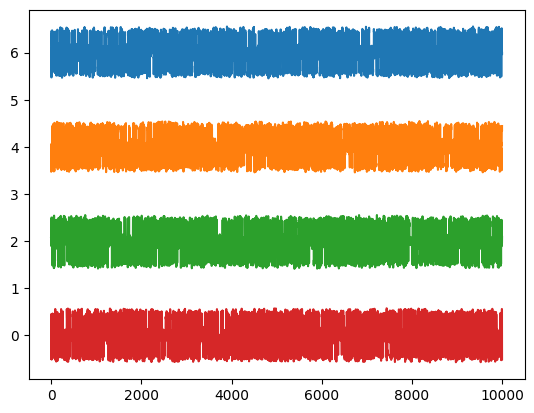

In [ ]:
# 受信信号をグラフにプロットしてみる
plt.plot(np.real(recv0) + 6)
plt.plot(np.imag(recv0) + 4)
plt.plot(np.real(recv1) + 2)
plt.plot(np.imag(recv1) + 0)

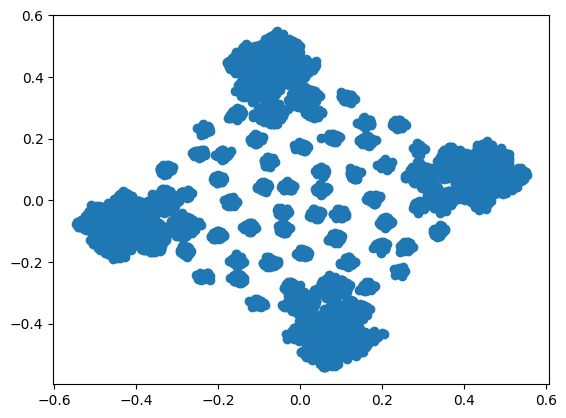

In [32]:
# I/Q平面にプロット
plt.scatter(np.real(recv0), np.imag(recv0))

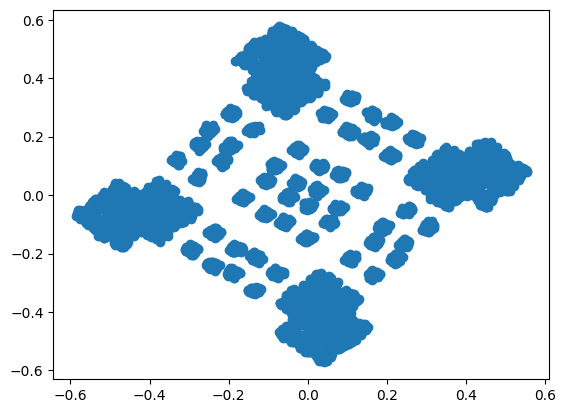

In [31]:
# I/Q平面にプロット
plt.scatter(np.real(recv1), np.imag(recv1))